# Mean Coefficient Density Analysis Across 20 Instances

This notebook computes the mean and standard deviation of coefficient density across all 20 NK landscape instances for each (n, k) pair.

## 1. Setup and Configuration

Import libraries and configure the folder path.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from pathlib import Path
from scipy.special import comb

sns.set_theme(style="whitegrid")

# Set the folder path (e.g., "./n1000_k3", "./n1000_k2", etc.)
folder_path = "./n1000_k3"

# Find all instance CSV files
instance_files = sorted(glob.glob(f"{folder_path}/instance_*.csv"))
print(f"Found {len(instance_files)} instances in {folder_path}")
print(f"Files: {instance_files[:3]}...")  # Show first 3
print()

Found 20 instances in ./n1000_k3
Files: ['./n1000_k3/instance_01.csv', './n1000_k3/instance_02.csv', './n1000_k3/instance_03.csv']...



## 2. Extract n and k Parameters

Determine n and k from the first instance.

In [3]:
# Load first instance to extract n and k
df_first = pd.read_csv(instance_files[0])

n = int(max(df_first[df_first['order'] > 0]['indices'].dropna().apply(
    lambda x: max([int(i) for i in str(x).split(';') if i])
))) + 1 if len(df_first[df_first['order'] > 0]) > 0 else None

max_order = int(df_first['order'].max())
k = max_order - 1  # Since max order = k + 1 for NK landscape

print(f"Parameters: n={n}, k={k}")
print()

Parameters: n=1000, k=3



## 3. Compute Density Across All 20 Instances

Load each instance and compute density for each order.

In [5]:
# Store density data for each order across all instances
all_densities = {}  # order -> [density1, density2, ..., density20]
all_actual_counts = {}  # order -> [count1, count2, ..., count20]

print(f"Processing {len(instance_files)} instances...")

for instance_file in instance_files:
    df_inst = pd.read_csv(instance_file)
    
    for order in sorted(df_inst['order'].unique()):
        if order == 0:  # Skip intercept
            continue
        
        actual_count = len(df_inst[df_inst['order'] == order])
        
        # Theoretical max
        if order == 1:
            theoretical_max = n
        else:
            theoretical_max = int(n * comb(k + 1, int(order), exact=True))
        
        ratio = (actual_count / theoretical_max * 100) if theoretical_max > 0 else 0
        
        if order not in all_densities:
            all_densities[order] = []
            all_actual_counts[order] = []
        
        all_densities[order].append(ratio)
        all_actual_counts[order].append(actual_count)

# Recompute max_order across all instances to ensure interpretation covers all orders
if len(all_densities) > 0:
    observed_max_order = max(all_densities.keys())
    try:
        if observed_max_order > max_order:
            max_order = int(observed_max_order)
            k = int(max_order) - 1
    except NameError:
        # If max_order wasn't defined earlier, set from observed
        max_order = int(observed_max_order)
        k = int(max_order) - 1

print("Done!")
print()

Processing 20 instances...
Done!



## 4. Compute Statistics and Display Table

Calculate mean, standard deviation, and other statistics for each order.

In [6]:
# Compute mean and std for each order
mean_analysis = []
for order in sorted(all_densities.keys()):
    densities = all_densities[order]
    actual_counts = all_actual_counts[order]
    
    mean_density = np.mean(densities)
    std_density = np.std(densities)
    min_density = np.min(densities)
    max_density = np.max(densities)
    
    if order == 1:
        theoretical_max = n
    else:
        theoretical_max = int(n * comb(k + 1, int(order), exact=True))
    
    mean_count = np.mean(actual_counts)
    std_count = np.std(actual_counts)
    
    mean_analysis.append({
        'order': int(order),
        'theoretical_max': int(theoretical_max),
        'mean_count': float(mean_count),
        'std_count': float(std_count),
        'mean_density': float(mean_density),
        'std_density': float(std_density),
        'min_density': float(min_density),
        'max_density': float(max_density)
    })

mean_df = pd.DataFrame(mean_analysis)

print(f"Density Statistics Across 20 Instances (n={n}, k={k})")
print("="*100)
print("Order | Theo Max | Mean Count | Std Count | Mean Density % | Std % | Min % | Max %")
print("-"*100)
for _, row in mean_df.iterrows():
    print(f"{int(row['order']):5d} | {int(row['theoretical_max']):8d} | "
          f"{row['mean_count']:10.1f} | {row['std_count']:9.2f} | "
          f"{row['mean_density']:13.2f} | {row['std_density']:5.2f} | "
          f"{row['min_density']:5.1f} | {row['max_density']:5.1f}")
print()

Density Statistics Across 20 Instances (n=1000, k=3)
Order | Theo Max | Mean Count | Std Count | Mean Density % | Std % | Min % | Max %
----------------------------------------------------------------------------------------------------
    1 |     1000 |     1000.0 |      0.00 |        100.00 |  0.00 | 100.0 | 100.0
    2 |     6000 |     5967.7 |      6.56 |         99.46 |  0.11 |  99.2 |  99.6
    3 |     4000 |     3999.9 |      0.30 |        100.00 |  0.01 | 100.0 | 100.0
    4 |     1000 |     1000.0 |      0.00 |        100.00 |  0.00 | 100.0 | 100.0



## 5. Visualization: Mean Density with Error Bars

Plot mean density across instances with standard deviation error bars.

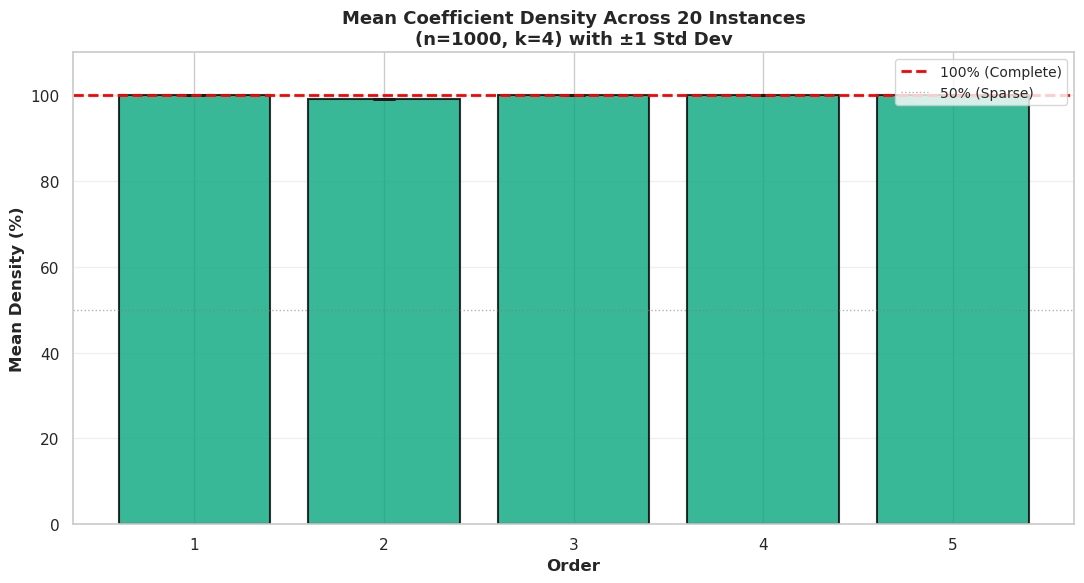

In [20]:
fig, ax = plt.subplots(figsize=(11, 6))

x = mean_df['order']
mean = mean_df['mean_density']
std = mean_df['std_density']

# Color based on mean density
colors = ['#d62828' if m < 50 else '#f77f00' if m < 80 else '#06a77d' for m in mean]

bars = ax.bar(x, mean, yerr=std, capsize=8, color=colors, alpha=0.8, 
              edgecolor='black', linewidth=1.5, error_kw={'elinewidth': 2.5, 'capthick': 2})

# Reference lines
ax.axhline(y=100, color='red', linestyle='--', linewidth=2, label='100% (Complete)')
ax.axhline(y=50, color='gray', linestyle=':', linewidth=1, alpha=0.6, label='50% (Sparse)')

ax.set_xlabel('Order', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Density (%)', fontsize=12, fontweight='bold')
ax.set_title(f'Mean Coefficient Density Across 20 Instances\n(n={n}, k={k}) with ±1 Std Dev', 
             fontsize=13, fontweight='bold')
ax.set_ylim([0, 110])
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Visualization: Actual Count Distribution

Show how actual coefficient counts vary across instances.

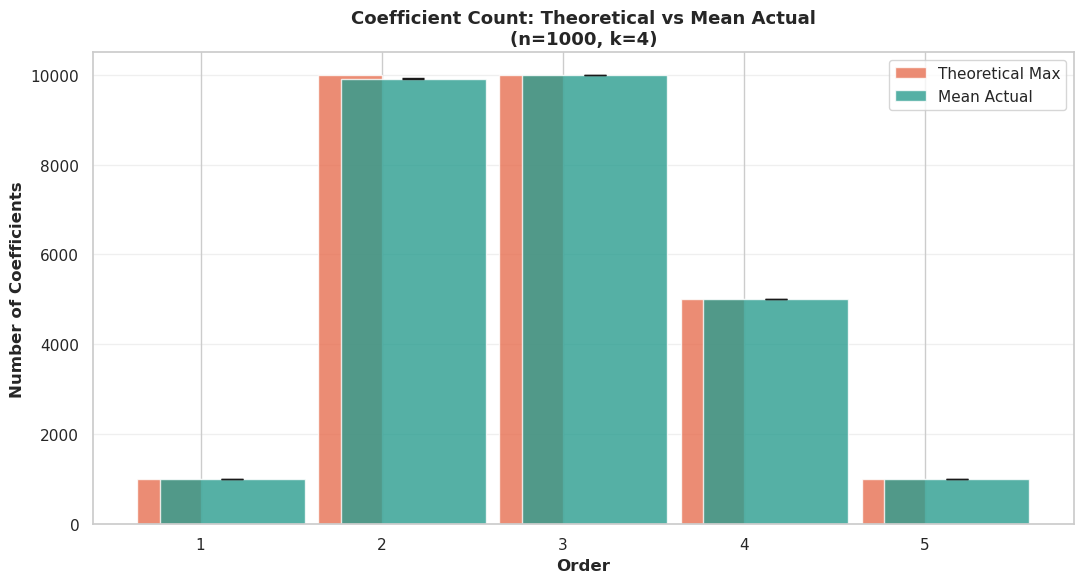

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))

x = mean_df['order']
mean_count = mean_df['mean_count']
std_count = mean_df['std_count']
theo_max = mean_df['theoretical_max']

# Plot both theoretical and actual
width = 0.35
ax.bar(x - width/2, theo_max, width, label='Theoretical Max', color='#e76f51', alpha=0.8)
ax.bar(x + width/2, mean_count, yerr=std_count, capsize=8, label='Mean Actual', 
       color='#2a9d8f', alpha=0.8, error_kw={'elinewidth': 2})

ax.set_xlabel('Order', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Coefficients', fontsize=12, fontweight='bold')
ax.set_title(f'Coefficient Count: Theoretical vs Mean Actual\n(n={n}, k={k})', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Line Plot: Coefficient Trends Across Orders

Visualize the trend of theoretical vs actual coefficients across interaction orders.



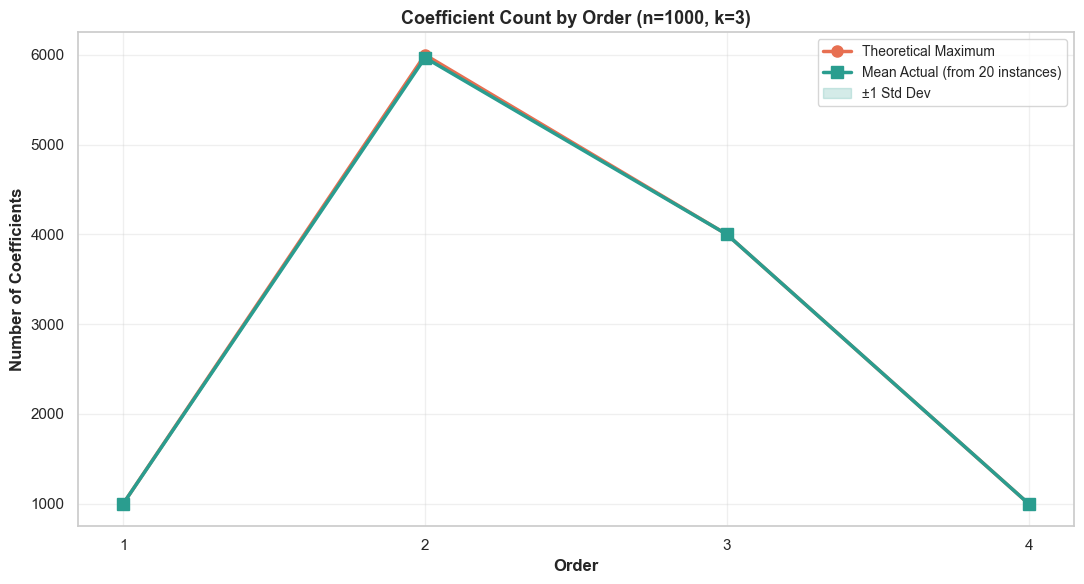

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))

# Theoretical vs Mean Actual (line plot)
ax.plot(mean_df['order'], mean_df['theoretical_max'], marker='o', linewidth=2.5, 
        markersize=8, label='Theoretical Maximum', color='#e76f51')
ax.plot(mean_df['order'], mean_df['mean_count'], marker='s', linewidth=2.5, 
        markersize=8, label='Mean Actual (from 20 instances)', color='#2a9d8f')

# Add error band for actual counts
ax.fill_between(mean_df['order'], 
                mean_df['mean_count'] - mean_df['std_count'],
                mean_df['mean_count'] + mean_df['std_count'],
                alpha=0.2, color='#2a9d8f', label='±1 Std Dev')

ax.set_xlabel('Order', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Coefficients', fontsize=12, fontweight='bold')
ax.set_title(f'Coefficient Count by Order (n={n}, k={k})', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(mean_df['order'])

plt.tight_layout()
plt.show()


## 8. Interpretation and Summary

Analyze the results and provide insights.


In [23]:
print("\nINTERPRETATION:")
print("="*80)

for _, row in mean_df.iterrows():
    order = int(row['order'])
    mean_dens = row['mean_density']
    std_dens = row['std_density']
    theo = row['theoretical_max']
    mean_cnt = row['mean_count']
    
    print(f"\nOrder {order}:")
    print(f"  - Theoretical Maximum: {theo:,} coefficients")
    print(f"  - Mean Actual: {mean_cnt:.1f} ± {row['std_count']:.2f}")
    print(f"  - Mean Density: {mean_dens:.2f}% ± {std_dens:.2f}%")
    print(f"  - Range: {row['min_density']:.2f}% to {row['max_density']:.2f}%")
    
    if mean_dens > 95:
        print(f"  - Status: ✓ COMPLETE (nearly all coefficients present)")
    elif mean_dens > 80:
        print(f"  - Status: ◐ MOSTLY COMPLETE (high density)")
    elif mean_dens > 50:
        print(f"  - Status: ◑ MODERATE (moderate sparsity)")
    else:
        print(f"  - Status: ◒ SPARSE (many missing coefficients)")

print("\n" + "="*80)
print(f"\nNote: All values are averaged across 20 independent instances.")
print(f"Low std dev indicates consistent behavior; high std dev indicates variability.")


INTERPRETATION:

Order 1:
  - Theoretical Maximum: 1,000.0 coefficients
  - Mean Actual: 1000.0 ± 0.00
  - Mean Density: 100.00% ± 0.00%
  - Range: 100.00% to 100.00%
  - Status: ✓ COMPLETE (nearly all coefficients present)

Order 2:
  - Theoretical Maximum: 10,000.0 coefficients
  - Mean Actual: 9909.0 ± 9.72
  - Mean Density: 99.09% ± 0.10%
  - Range: 98.82% to 99.22%
  - Status: ✓ COMPLETE (nearly all coefficients present)

Order 3:
  - Theoretical Maximum: 10,000.0 coefficients
  - Mean Actual: 10000.0 ± 0.22
  - Mean Density: 100.00% ± 0.00%
  - Range: 99.99% to 100.00%
  - Status: ✓ COMPLETE (nearly all coefficients present)

Order 4:
  - Theoretical Maximum: 5,000.0 coefficients
  - Mean Actual: 5000.0 ± 0.00
  - Mean Density: 100.00% ± 0.00%
  - Range: 100.00% to 100.00%
  - Status: ✓ COMPLETE (nearly all coefficients present)

Order 5:
  - Theoretical Maximum: 1,000.0 coefficients
  - Mean Actual: 1000.0 ± 0.00
  - Mean Density: 100.00% ± 0.00%
  - Range: 100.00% to 100.00%
 